# Deepfake Detection — Benchmarking Notebook

**EE656 Course Project**

This notebook provides a unified evaluation of four deepfake detection architectures:

| Model | Paradigm | Architecture |
|---|---|---|
| Meso4 | Lightweight CNN | 4-layer mesoscopic feature extractor |
| Xception | Deep CNN | Depthwise separable convolutions |
| Patch ResNet Layer1 | Patch-based | ResNet18 over non-overlapping patches |
| Multiple Attention Detector | Attention | ResNet18 + Spatial/Channel attention |

---

**Reference:** Jingyi Deng et al., *Towards Benchmarking and Evaluating Deepfake Detection*,  
IEEE Transactions on Dependable and Secure Computing, 2024.

## 0. Configuration

Edit the paths below to match your environment before running.

In [1]:
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_ROOT    = Path("dataset")        # root directory of face images
METADATA     = Path("metadata.csv")  # metadata CSV
WEIGHTS_DIR  = Path("weights")       # directory containing .pth checkpoints
RESULTS_DIR  = Path("results")       # directory containing training log CSVs
OUTPUT_DIR   = Path("benchmark_output")  # where this notebook saves figures / tables

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Models ────────────────────────────────────────────────────────────────────
MODELS = {
    "meso4":              "Meso4",
    "xception":           "Xception",
    "patch_resnet":       "Patch ResNet",
    "multiple_attention": "Multiple Attention",
}
CHECKPOINT_TYPE = "best_mcc" # CHECKPOINT_TYPE = "best_mcc" determines which saved checkpoint is benchmarked for every model.
IMAGE_SIZE  = 256
BATCH_SIZE  = 32
DEVICE_STR  = "cuda"   # change to "cpu" if no GPU

## 1. Environment Setup

In [5]:
import sys
import time
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)

try:
    from fvcore.nn import FlopCountAnalysis
    FVCORE_AVAILABLE = True
except ImportError:
    FVCORE_AVAILABLE = False
    print("fvcore not found — FLOPs will be skipped. Install with: pip install fvcore")

from data.dataset import DeepfakeDataset, get_normalization
from models import Meso4, XceptionDetector, PatchResNet, MultipleAttentionDetector

device = torch.device(DEVICE_STR if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"PyTorch: {torch.__version__}")

# Publication-quality plot style
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "legend.fontsize":   10,
    "figure.dpi":        120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.35,
})

MODEL_COLORS = {
    "meso4":              "#E15759",
    "xception":           "#4E79A7",
    "patch_resnet":       "#59A14F",
    "multiple_attention": "#F28E2B",
}

Device : cuda
PyTorch: 2.11.0+cu128


## 2. Load Training Logs

In [6]:
logs: dict[str, pd.DataFrame] = {}

for model_key in MODELS:
    log_path = RESULTS_DIR / f"{model_key}_training_log.csv"
    if log_path.exists():
        logs[model_key] = pd.read_csv(log_path)
        print(f"  Loaded log for {MODELS[model_key]:25s}: {len(logs[model_key])} epochs")
    else:
        print(f"  [MISSING] {log_path}")

print(f"\n{len(logs)}/{len(MODELS)} training logs found.")

  Loaded log for Meso4                    : 19 epochs
  Loaded log for Xception                 : 12 epochs
  Loaded log for Patch ResNet             : 9 epochs
  Loaded log for Multiple Attention       : 9 epochs

4/4 training logs found.


## 3. Training Curves

Loss and accuracy curves help diagnose underfitting, overfitting, and learning stability.

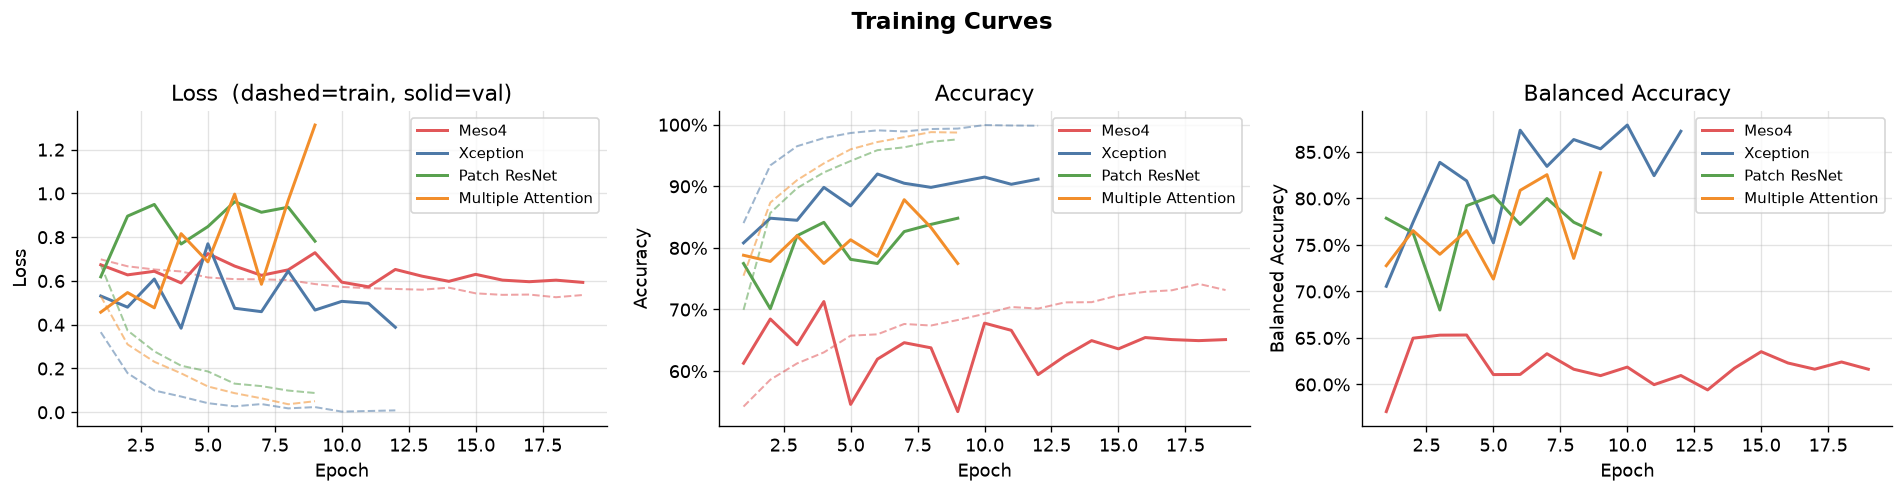

In [7]:
def plot_training_curves(logs, output_dir):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    metrics = [
        ("train_loss",            "val_loss",             "Loss"),
        ("train_accuracy",        "val_accuracy",         "Accuracy"),
        (None,                    "val_balanced_accuracy", "Balanced Accuracy"),
    ]

    for ax, (train_col, val_col, ylabel) in zip(axes, metrics):
        for model_key, df in logs.items():
            color = MODEL_COLORS[model_key]
            label = MODELS[model_key]
            if train_col and train_col in df.columns:
                ax.plot(
                    df["epoch"], df[train_col],
                    linestyle="--", color=color, alpha=0.55, linewidth=1.2,
                )
            if val_col in df.columns:
                ax.plot(
                    df["epoch"], df[val_col],
                    linestyle="-", color=color, linewidth=1.8, label=label,
                )

        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend(fontsize=9)
        if "Accuracy" in ylabel:
            ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

    axes[0].set_title("Loss  (dashed=train, solid=val)")
    fig.suptitle("Training Curves", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    fig.savefig(output_dir / "training_curves.png", bbox_inches="tight", dpi=150)
    plt.show()

plot_training_curves(logs, OUTPUT_DIR)

## 4. Load Checkpoints and Evaluate on Test Set

All four models are evaluated under identical conditions on the held-out test split.

In [8]:
def build_model(name: str) -> nn.Module:
    name = name.lower()
    if name == "meso4":              return Meso4()
    if name == "xception":           return XceptionDetector(pretrained=True)
    if name == "patch_resnet":       return PatchResNet(pretrained=True)
    if name == "multiple_attention": return MultipleAttentionDetector(pretrained=True)
    raise ValueError(f"Unknown model: {name}")


def load_checkpoint(model, path, device):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return ckpt


def build_test_loader(model_key: str, image_size: int, batch_size: int) -> DataLoader:
    norm = get_normalization(model_key)
    ds = DeepfakeDataset(
        dataset_root=DATA_ROOT,
        metadata_file=METADATA,
        split="test",
        image_size=image_size,
        normalization=norm,
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)


@torch.no_grad()
def run_inference(model, loader, device):
    """Return (labels, probs) numpy arrays."""
    all_labels, all_probs = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        logits = model(images).squeeze(1)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_labels.extend(labels.numpy().tolist())
        all_probs.extend(probs.tolist())
    return np.array(all_labels), np.array(all_probs)


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob > threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return {
        "accuracy":          accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision":         precision_score(y_true, y_pred, zero_division=0),
        "recall":            recall_score(y_true, y_pred, zero_division=0),
        "specificity":       specificity,
        "f1":                f1_score(y_true, y_pred, zero_division=0),
        "roc_auc":           roc_auc_score(y_true, y_prob),
        "pr_auc":            average_precision_score(y_true, y_prob),
        "mcc":               matthews_corrcoef(y_true, y_pred),
        "confusion":         cm,
    }

def checkpoint_size_mb(path):
    return os.path.getsize(path) / (1024**2)

@torch.no_grad()
def benchmark_fps(model, device, image_size=256, runs=200, warmup=20):

    model.eval()

    x = torch.randn(
        1,
        3,
        image_size,
        image_size,
        device=device,
    )

    # warmup
    for _ in range(warmup):
        _ = model(x)

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()

    for _ in range(runs):
        _ = model(x)

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start

    fps = runs / elapsed
    latency_ms = 1000 / fps

    return fps, latency_ms

# ── Evaluate all models ────────────────────────────────────────────────────────
eval_results: dict[str, dict] = {}
predictions:  dict[str, tuple] = {}

for model_key, display_name in MODELS.items():
    ckpt_path = WEIGHTS_DIR / f"{model_key}_{CHECKPOINT_TYPE}.pth"
    if not ckpt_path.exists():
        print(f"  [SKIP] Checkpoint not found: {ckpt_path}")
        continue

    print(f"  Evaluating {display_name}...", end="", flush=True)
    model = build_model(model_key).to(device)
    ckpt = load_checkpoint(model, ckpt_path, device)
    

    print(
        f"  epoch={ckpt.get('epoch', '?')}  "
        f"loss={ckpt.get('best_val_loss', float('nan')):.4f}  "
        f"bal_acc={100*ckpt.get('best_bal_accuracy', float('nan')):.2f}%  "
        f"mcc={ckpt.get('best_mcc', float('nan')):.4f}"
    )
    test_loader = build_test_loader(model_key, IMAGE_SIZE, BATCH_SIZE)

    y_true, y_prob = run_inference(model, test_loader, device)
    metrics = compute_metrics(y_true, y_prob)

    eval_results[model_key] = metrics
    predictions[model_key] = (y_true, y_prob)

    # Save raw predictions for later analysis
    pd.DataFrame({
        "label": y_true,
        "probability": y_prob,
        "prediction": (y_prob >= 0.5).astype(int),
    }).to_csv(
        OUTPUT_DIR / f"{model_key}_predictions.csv",
        index=False,
    )

    print(f"  Accuracy={100*metrics['accuracy']:.1f}%  AUC={metrics['roc_auc']:.3f}")

print(f"\nEvaluation complete for {len(eval_results)}/{len(MODELS)} models.")

  Evaluating Meso4...  epoch=4  loss=0.5905  bal_acc=nan%  mcc=0.2884
[TEST ]    600 images  (real=150, fake=450)
  Accuracy=75.0%  AUC=0.537
  Evaluating Xception...  epoch=6  loss=0.3835  bal_acc=nan%  mcc=0.7804
[TEST ]    600 images  (real=150, fake=450)
  Accuracy=82.7%  AUC=0.879
  Evaluating Patch ResNet...  epoch=4  loss=0.6185  bal_acc=nan%  mcc=0.5804
[TEST ]    600 images  (real=150, fake=450)
  Accuracy=76.3%  AUC=0.788
  Evaluating Multiple Attention...  epoch=7  loss=0.4569  bal_acc=nan%  mcc=0.6681
[TEST ]    600 images  (real=150, fake=450)
  Accuracy=82.0%  AUC=0.841

Evaluation complete for 4/4 models.


## 5. Performance Summary Table

In [9]:
def format_pct(v): return f"{100*v:.2f}%"
def format_4(v):   return f"{v:.4f}"

rows = []
for model_key, m in eval_results.items():
    rows.append({
        "Model":             MODELS[model_key],
        "Accuracy":          format_pct(m["accuracy"]),
        "Balanced Acc.":     format_pct(m["balanced_accuracy"]),
        "Precision":         format_pct(m["precision"]),
        "Recall (fake)": format_pct(m["recall"]),
        "Specificity":       format_pct(m["specificity"]),
        "F1":                format_pct(m["f1"]),
        "ROC-AUC":           format_4(m["roc_auc"]),
        "PR-AUC":            format_4(m["pr_auc"]),
        "MCC":               format_4(m["mcc"]),
    })

perf_df = pd.DataFrame(rows)
print(perf_df.to_string(index=False))

perf_df.to_csv(OUTPUT_DIR / "performance_table.csv", index=False)
perf_df

             Model Accuracy Balanced Acc. Precision Recall (fake) Specificity     F1 ROC-AUC PR-AUC    MCC
             Meso4   75.00%        50.00%    75.00%       100.00%       0.00% 85.71%  0.5368 0.7881 0.0000
          Xception   82.67%        73.56%    86.04%        91.78%      55.33% 88.82%  0.8791 0.9531 0.5100
      Patch ResNet   76.33%        69.33%    84.84%        83.33%      55.33% 84.08%  0.7878 0.9119 0.3801
Multiple Attention   82.00%        72.89%    85.77%        91.11%      54.67% 88.36%  0.8411 0.9361 0.4925


,Model,Accuracy,Balanced Acc.,Precision,Recall (fake),Specificity,F1,ROC-AUC,PR-AUC,MCC
0,Meso4,75.00%,50.00%,75.00%,100.00%,0.00%,85.71%,0.5368,0.7881,0.0000
1,Xception,82.67%,73.56%,86.04%,91.78%,55.33%,88.82%,0.8791,0.9531,0.5100
2,Patch ResNet,76.33%,69.33%,84.84%,83.33%,55.33%,84.08%,0.7878,0.9119,0.3801
3,Multiple Attention,82.00%,72.89%,85.77%,91.11%,54.67%,88.36%,0.8411,0.9361,0.4925


## 6. ROC Curves

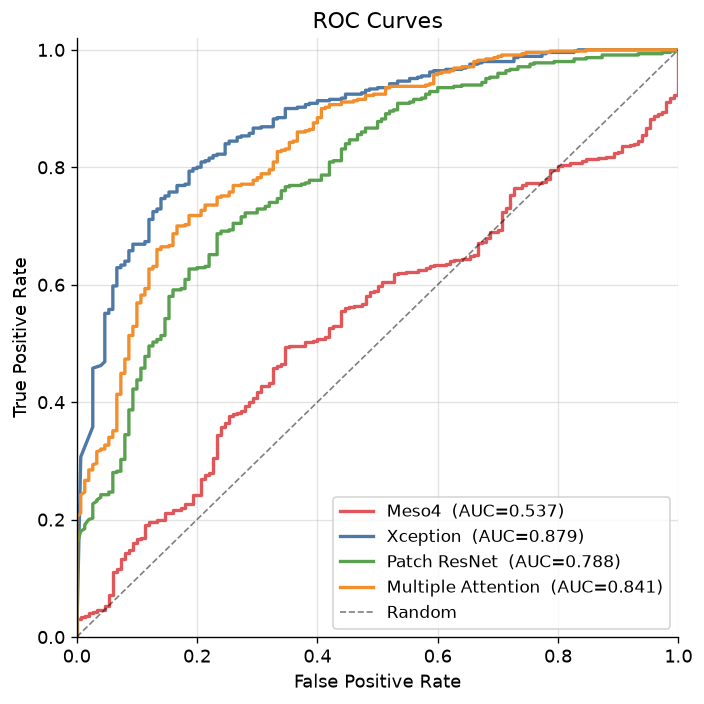

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))

for model_key, (y_true, y_prob) in predictions.items():
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = eval_results[model_key]["roc_auc"]
    ax.plot(
        fpr, tpr,
        color=MODEL_COLORS[model_key],
        linewidth=2,
        label=f"{MODELS[model_key]}  (AUC={auc:.3f})",
    )

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend(loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Precision-Recall Curves

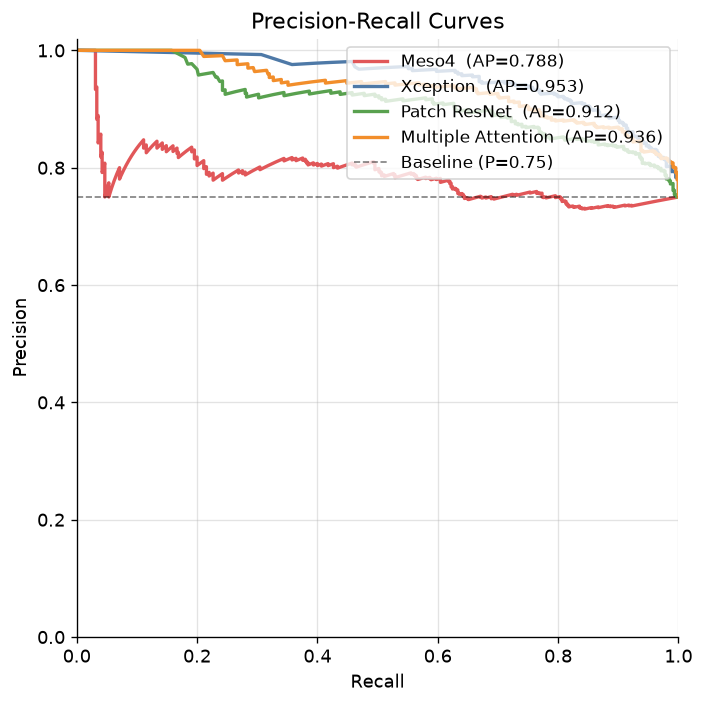

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))

for model_key, (y_true, y_prob) in predictions.items():
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = eval_results[model_key]["pr_auc"]
    ax.plot(
        rec, prec,
        color=MODEL_COLORS[model_key],
        linewidth=2,
        label=f"{MODELS[model_key]}  (AP={pr_auc:.3f})",
    )

baseline = np.array([y_true for _, (y_true, _) in predictions.items()][0]).mean()
ax.axhline(baseline, linestyle="--", color="k", linewidth=1, alpha=0.5, label=f"Baseline (P={baseline:.2f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves")
ax.legend(loc="upper right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Confusion Matrices

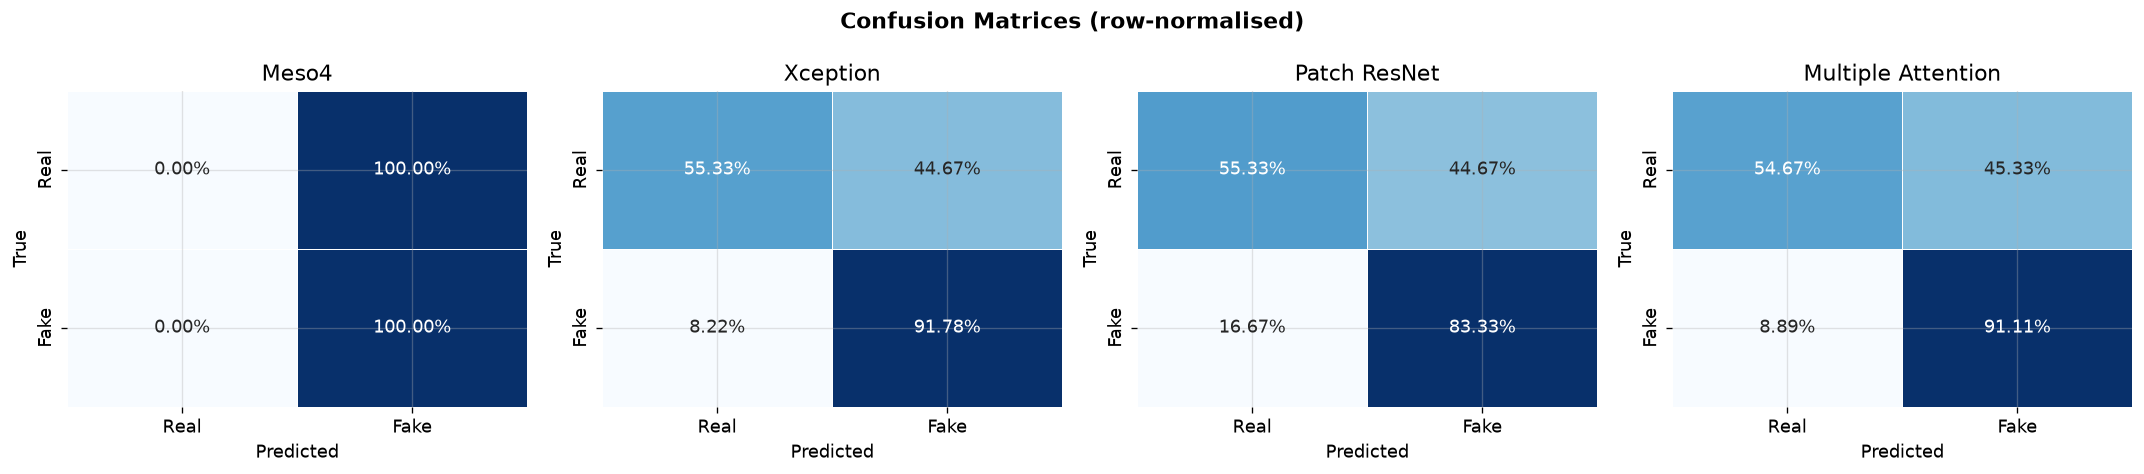

In [12]:
n_models = len(eval_results)
fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4))

if n_models == 1:
    axes = [axes]

for ax, (model_key, m) in zip(axes, eval_results.items()):
    cm = m["confusion"]
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        ax=ax,
        xticklabels=["Real", "Fake"],
        yticklabels=["Real", "Fake"],
        cbar=False,
        linewidths=0.5,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(MODELS[model_key])

fig.suptitle("Confusion Matrices (row-normalised)", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Model Complexity Analysis

Parameter count, estimated FLOPs, and model file size.

In [13]:
complexity_rows = []

dummy_input = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)

for model_key, display_name in MODELS.items():
    ckpt_path = WEIGHTS_DIR / f"{model_key}_{CHECKPOINT_TYPE}.pth"
    if not ckpt_path.exists():
        continue

    model = build_model(model_key).to("cpu")
    load_checkpoint(model, ckpt_path, torch.device("cpu"))

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    model_size_mb = ckpt_path.stat().st_size / 1024 / 1024

    gflops = float("nan")
    if FVCORE_AVAILABLE:
        try:
            flops = FlopCountAnalysis(model, dummy_input)
            flops.unsupported_ops_warnings(False)
            gflops = flops.total() / 1e9
        except Exception:
            pass

    complexity_rows.append({
        "Model":          display_name,
        "Parameters (M)": round(n_params / 1e6, 2),
        "GFLOPs": round(gflops, 2) if not np.isnan(gflops) else np.nan,
        "Model Size (MB)": round(model_size_mb, 1),
    })

complexity_df = pd.DataFrame(complexity_rows)
complexity_df.to_csv(OUTPUT_DIR / "model_complexity.csv", index=False)
complexity_df

,Model,Parameters (M),GFLOPs,Model Size (MB)
0,Meso4,0.03,0.06,0.3
1,Xception,20.81,5.98,238.6
2,Patch ResNet,11.18,2.38,128.0
3,Multiple Attention,12.92,2.48,148.0


## 10. Inference Speed Benchmark

Measures latency and throughput under identical conditions (same batch size, same device).

In [14]:
WARMUP_BATCHES   = 10
BENCHMARK_IMAGES = 500   # total images used to estimate throughput

speed_rows = []
dummy_batch = torch.zeros(BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)

for model_key, display_name in MODELS.items():
    ckpt_path = WEIGHTS_DIR / f"{model_key}_{CHECKPOINT_TYPE}.pth"
    if not ckpt_path.exists():
        continue

    model = build_model(model_key).to(device)
    load_checkpoint(model, ckpt_path, device)
    model.eval()

    # Warm-up
    with torch.no_grad():
        for _ in range(WARMUP_BATCHES):
            _ = model(dummy_batch)

    if device.type == "cuda":
        torch.cuda.synchronize()

    # Benchmark
    n_batches = max(1, BENCHMARK_IMAGES // BATCH_SIZE)
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(n_batches):
            _ = model(dummy_batch)

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - t0
    total_imgs = n_batches * BATCH_SIZE
    fps = total_imgs / elapsed
    latency_ms = elapsed / total_imgs * 1000

    speed_rows.append({
        "Model":            display_name,
        "FPS": round(fps, 1),
        "Latency (ms/img)": round(latency_ms, 2),
        "Device":           str(device),
    })
    print(f"  {display_name:25s}: {fps:.1f} img/s  ({latency_ms:.2f} ms/img)")

speed_df = pd.DataFrame(speed_rows)
speed_df.to_csv(OUTPUT_DIR / "inference_speed.csv", index=False)
speed_df

  Meso4                    : 6551.6 img/s  (0.15 ms/img)
  Xception                 : 336.2 img/s  (2.97 ms/img)
  Patch ResNet             : 1292.6 img/s  (0.77 ms/img)
  Multiple Attention       : 1240.4 img/s  (0.81 ms/img)


,Model,FPS,Latency (ms/img),Device
0,Meso4,6551.6,0.15,cuda
1,Xception,336.2,2.97,cuda
2,Patch ResNet,1292.6,0.77,cuda
3,Multiple Attention,1240.4,0.81,cuda


## 11. Performance vs. Efficiency Scatter Plot

Visualise the accuracy vs. throughput trade-off — a key question in practical deployment.

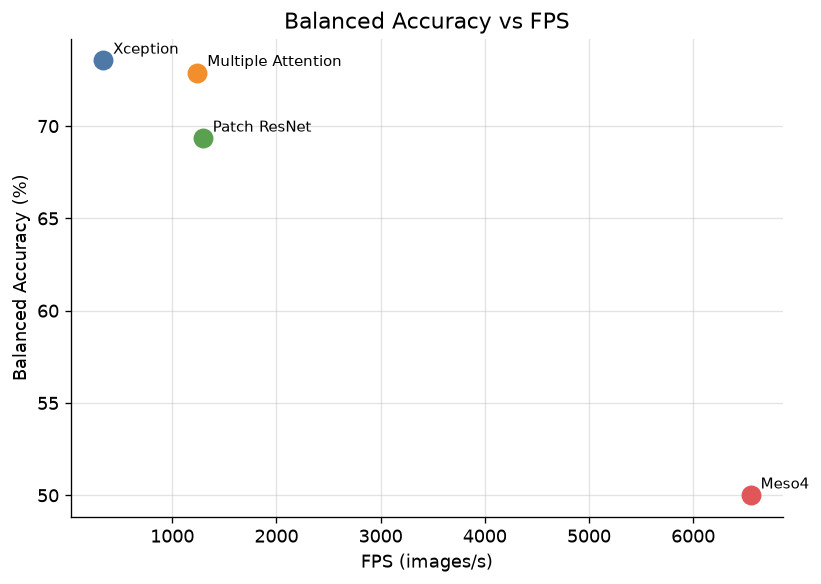

In [15]:
if speed_rows and eval_results:
    fig, ax = plt.subplots(figsize=(7, 5))

    for model_key in eval_results:
        # Match speed row
        speed_row = next(
            (r for r in speed_rows if r["Model"] == MODELS[model_key]), None
        )
        if speed_row is None:
            continue

        acc = 100 * eval_results[model_key]["balanced_accuracy"]
        fps = float(speed_row["FPS"])

        ax.scatter(fps, acc, s=120, color=MODEL_COLORS[model_key], zorder=5)
        ax.annotate(
            MODELS[model_key],
            (fps, acc),
            textcoords="offset points",
            xytext=(6, 4),
            fontsize=9,
        )

    ax.set_xlabel("FPS (images/s)")
    ax.set_ylabel("Balanced Accuracy (%)")
    ax.set_title("Balanced Accuracy vs FPS")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "accuracy_vs_fps.png", dpi=150, bbox_inches="tight")
    plt.show()

## 12. Parameter Count Comparison

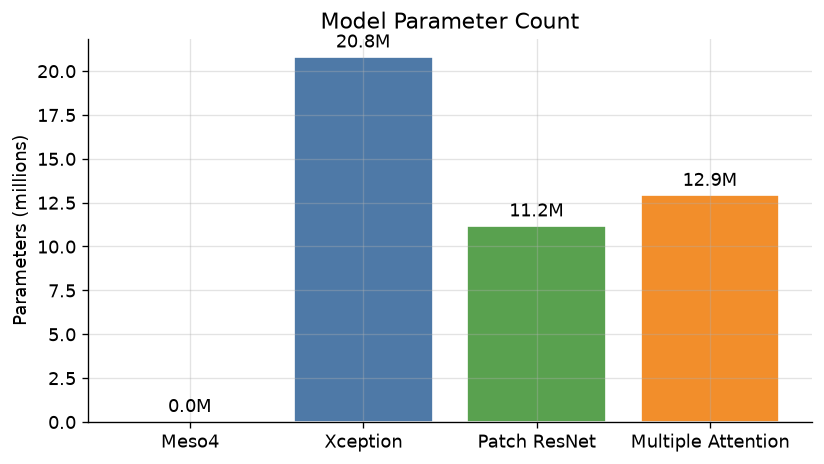

In [ ]:
if complexity_rows:

    names  = [r["Model"] for r in complexity_rows]
    params = [float(r["Parameters (M)"]) for r in complexity_rows]

    fig, ax = plt.subplots(figsize=(7, 4))

    bars = ax.bar(
        names,
        params,
        color=list(MODEL_COLORS.values())[:len(names)],
        edgecolor="white",
    )

    # Custom labels
    for bar, p in zip(bars, params):

        if p < 0.1:
            label = f"{int(round(p * 1000))}K"     # 0.03M -> 30K
            offset = 0.08
        else:
            label = f"{p:.1f}M"
            offset = 0.20

        ax.text(
            bar.get_x() + bar.get_width()/2,
            p + offset,
            label,
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
        )

    ax.set_ylabel("Parameters (millions)")
    ax.set_title("Model Parameter Count")

    plt.tight_layout()

    fig.savefig(
        OUTPUT_DIR / "parameter_count.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

## 13. Comprehensive Benchmark Table

Single combined table merging performance, complexity, and speed metrics — suitable for inclusion in a report.

In [19]:
combined_rows = []

for model_key in eval_results:
    m = eval_results[model_key]

    complexity_row = next(
        (r for r in complexity_rows if r["Model"] == MODELS[model_key]), {}
    )
    speed_row = next(
        (r for r in speed_rows if r["Model"] == MODELS[model_key]), {}
    )

    combined_rows.append({
        "Model":             MODELS[model_key],
        # Detection performance
        "Accuracy (%)": f"{100*m['accuracy']:.2f}",
        "Bal. Acc. (%)": f"{100*m['balanced_accuracy']:.2f}",
        "F1 (%)": f"{100*m['f1']:.2f}",
        "ROC-AUC": f"{m['roc_auc']:.4f}",
        "PR-AUC": f"{m['pr_auc']:.4f}",
        "MCC": f"{m['mcc']:.4f}",
        # Complexity
        "Parameters (M)":        complexity_row.get("Parameters (M)", "N/A"),
        "Model Size (MB)": complexity_row.get("Model Size (MB)", "N/A"),
        "GFLOPs":            complexity_row.get("GFLOPs", "N/A"),
        # Speed
        "FPS": speed_row.get("FPS", "N/A"),
        "Latency (ms/img)": speed_row.get("Latency (ms/img)", "N/A"),
    })

combined_df = pd.DataFrame(combined_rows)
combined_df.to_csv(OUTPUT_DIR / "benchmark_combined.csv", index=False)
print(combined_df.to_string(index=False))
combined_df

             Model Accuracy (%) Bal. Acc. (%) F1 (%) ROC-AUC PR-AUC    MCC  Parameters (M)  Model Size (MB)  GFLOPs    FPS  Latency (ms/img)
             Meso4        75.00         50.00  85.71  0.5368 0.7881 0.0000            0.03              0.3    0.06 6551.6              0.15
          Xception        82.67         73.56  88.82  0.8791 0.9531 0.5100           20.81            238.6    5.98  336.2              2.97
      Patch ResNet        76.33         69.33  84.08  0.7878 0.9119 0.3801           11.18            128.0    2.38 1292.6              0.77
Multiple Attention        82.00         72.89  88.36  0.8411 0.9361 0.4925           12.92            148.0    2.48 1240.4              0.81


,Model,Accuracy (%),Bal. Acc. (%),F1 (%),ROC-AUC,PR-AUC,MCC,Parameters (M),Model Size (MB),GFLOPs,FPS,Latency (ms/img)
0,Meso4,75.00,50.00,85.71,0.5368,0.7881,0.0000,0.03,0.3,0.06,6551.6,0.15
1,Xception,82.67,73.56,88.82,0.8791,0.9531,0.5100,20.81,238.6,5.98,336.2,2.97
2,Patch ResNet,76.33,69.33,84.08,0.7878,0.9119,0.3801,11.18,128.0,2.38,1292.6,0.77
3,Multiple Attention,82.00,72.89,88.36,0.8411,0.9361,0.4925,12.92,148.0,2.48,1240.4,0.81


## 14. Discussion

This section records key observations from the benchmark.
Edit this cell after running the notebook to fill in your findings.

### Detection Performance

*(Fill in after running the evaluation cells.)*

- **Meso4** is the lightest model with fewest parameters. As a shallow CNN trained from scratch it typically shows the lowest accuracy but fastest inference.
- **Xception** serves as the deep CNN baseline. It achieves a strong accuracy/efficiency trade-off and is one of the most widely cited deepfake detectors.
- **Patch ResNet** focuses on local forgery artifacts. It may outperform global classifiers when forgeries are localised to small facial regions.
- **Multiple Attention Detector** combines spatial and channel attention on a ResNet18 backbone, emphasising discriminative regions.

### Efficiency Trade-offs

The parameter count comparison reveals the wide range in model sizes.  
Meso4 is the most deployment-friendly option; transformer-based and deep models trade efficiency for capacity.

### Limitations

- This benchmark evaluates on FaceForensics++ only; cross-dataset generalisation is not tested here.
- Robustness under JPEG compression, Gaussian noise, and resolution changes is left for future work.
- Results depend on the quality of the face-detection and alignment preprocessing pipeline.

## 15. Save All Outputs

In [20]:
print(f"All outputs saved to: {OUTPUT_DIR.resolve()}")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name}")

All outputs saved to: C:\Users\kusha\Deepfake-Evaluation-and-Benchmarking\benchmark_output
  accuracy_vs_fps.png
  benchmark_combined.csv
  confusion_matrices.png
  inference_speed.csv
  meso4_predictions.csv
  model_complexity.csv
  multiple_attention_predictions.csv
  parameter_count.png
  patch_resnet_predictions.csv
  performance_table.csv
  pr_curves.png
  roc_curves.png
  training_curves.png
  xception_predictions.csv
